# Nian-Ya Weng — Individual Model Notebook
**Branch:** `main`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): ResNet-50 + LSTM
- **Model 2** (Phase 3): ResNet-50 + Bahdanau Attention + LSTM with Dropout
  - Dropout hyperparameter tuning: compared Dropout 0.5 vs Dropout 0.3; Dropout 0.5 selected as final model
  - Final comparison between Model 1 and Model 2 (Dropout 0.5) using BLEU-1 to BLEU-4 and ROUGE-L

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs saved to the local `processed/` folder before running this notebook.

## 0. Install dependencies

In [46]:
!pip install -q torch torchvision nltk Pillow matplotlib

## 1. Load processed data

In [47]:
from pathlib import Path

# Set local paths for processed data and checkpoints
LOCAL_FOLDER    = Path.home() / 'Desktop' / 'dl-image-captioning-at3'
DRIVE_PROCESSED = LOCAL_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = LOCAL_FOLDER / 'checkpoints'

STUDENT_NAME = 'nian-ya'
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Check all required files
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'Found' if p.exists() else 'MISSING'
    print(f'{p.name}: {status}')

# Confirm number of images available
n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'available: images_224/: {n_imgs:,} images found')

vocab.pkl: Found
splits.json: Found
captions_clean.json: Found
available: images_224/: 7,750 images found


In [48]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

# Load train/val/test image splits
with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)
# Load cleaned captions and image
with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


## 2. Imports & device setup

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use Apple System MPS to runing
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


## 3. Dataset & DataLoader

In [50]:
class VizWizDataset(Dataset):
    """Loads 224x224 images from Drive and tokenised captions from memory."""

    def __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((img_dir / fname, indices))

        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption_indices = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), torch.tensor(caption_indices, dtype=torch.long)


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)

In [51]:
BATCH_SIZE = 32

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 938  Val: 118  Test: 118


---
# Model 1 — Phase 2 (Individual Architecture)

## Architecture Rationale

**Encoder:** Pre-trained ResNet-50 (ImageNet weights). The classification head is removed and replaced with a linear projection layer that maps the 2048-d feature vector to `embed_size`. The convolutional layers are frozen during training to reduce computation and prevent overfitting, while only the projection layer is fine-tuned.

**Decoder:** Single-layer LSTM with an embedding layer and a linear output projection to vocabulary size. The image feature vector is used as the initial hidden state of the LSTM. Teacher forcing is applied during training.

**Design decisions:**
- ResNet-50 chosen for its strong feature extraction and wide adoption as a captioning baseline
- LSTM chosen over GRU for its proven performance on sequence generation tasks
- Embedding size and hidden size set to 256 for a balance between capacity and training speed

In [52]:
class EncoderCNN(nn.Module):
    """Feature extractor using pre-trained ResNet-50."""

    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove classification head
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        # Freeze all ResNet layers
        for param in self.resnet.parameters():
            param.requires_grad = False
        # Project 2048-d features to embed_size
        self.project = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)        # (batch, 2048, 1, 1)
        features = features.squeeze(-1).squeeze(-1)  # (batch, 2048)
        return self.bn(self.project(features))        # (batch, embed_size)


class DecoderRNN(nn.Module):
    """Caption generator using LSTM with teacher forcing."""

    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.feature_proj = nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):
        # captions: (batch, seq_len) including SOS but excluding last token
        embeddings = self.embedding(captions[:, :-1])         # (batch, seq_len-1, embed_size)
        # Use image features as initial hidden state
        h0 = self.feature_proj(features).unsqueeze(0)                          # (1, batch, hidden_size)
        c0 = torch.zeros_like(h0)
        outputs, _ = self.lstm(embeddings, (h0, c0))          # (batch, seq_len-1, hidden_size)
        return self.fc(outputs)                               # (batch, seq_len-1, vocab_size)

    def generate(self, features, max_len=20):
        inputs = torch.tensor([[SOS_IDX]], device=features.device)
        h = self.feature_proj(features).unsqueeze(0)
        c = torch.zeros_like(h)
        result = []
        for _ in range(max_len):
            emb = self.embedding(inputs)                      # (1, 1, embed_size)
            out, (h, c) = self.lstm(emb, (h, c))
            pred = self.fc(out.squeeze(1)).argmax(dim=-1)     # (1,)
            token = pred.item()
            if token == EOS_IDX:
                break
            result.append(token)
            inputs = pred.unsqueeze(0)
        return result

### Model 1 — Training

Epoch 1/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.7266 | Val Loss: 3.3284
  ✓ Best model saved (val_loss=3.3284)


Epoch 2/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 3.0114 | Val Loss: 3.1523
  ✓ Best model saved (val_loss=3.1523)


Epoch 3/15:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 13/15 | Train Loss: 1.1910 | Val Loss: 3.8213


Epoch 14/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 1.1213 | Val Loss: 3.8942


Epoch 15/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 1.0596 | Val Loss: 3.9999


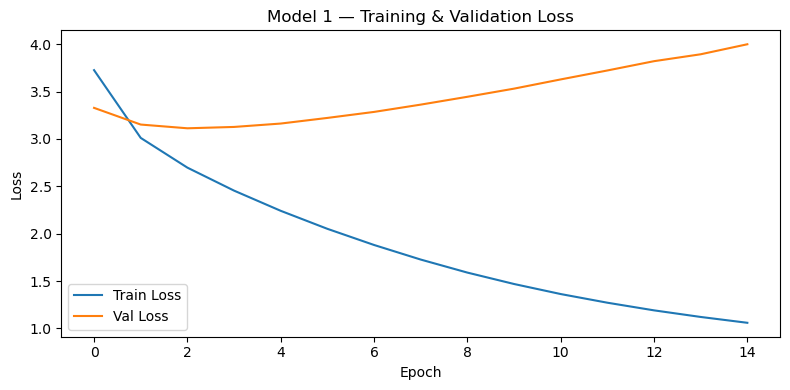

In [53]:
from tqdm.notebook import tqdm

# Hyperparameters
EMBED_SIZE  = 256
HIDDEN_SIZE = 512
NUM_LAYERS  = 1
EPOCHS      = 15
LR_DECODER  = 1e-3
LR_ENCODER  = 1e-4

encoder1 = EncoderCNN(EMBED_SIZE).to(DEVICE)
decoder1 = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam([
    {'params': decoder1.parameters(), 'lr': LR_DECODER},
    {'params': encoder1.project.parameters(), 'lr': LR_ENCODER},
    {'params': encoder1.bn.parameters(), 'lr': LR_ENCODER},
])

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────
    encoder1.train()
    decoder1.train()
    running_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        features = encoder1(images)
        outputs  = decoder1(features, captions)

        targets = captions[:, 1:]
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder1.parameters(), max_norm=5)
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────
    encoder1.eval()
    decoder1.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            features = encoder1(images)
            outputs  = decoder1(features, captions)
            targets  = captions[:, 1:]
            loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # ── Save best checkpoint ───────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'encoder': encoder1.state_dict(),
            'decoder': decoder1.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_loss': val_loss,
        }, MY_CHECKPTS / 'model1_best.pth')
        print(f'  ✓ Best model saved (val_loss={val_loss:.4f})')

# ── Plot loss curves ───────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 1 — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model1_loss.png')
plt.show()

### Model 1 — Evaluation (BLEU-1 to BLEU-4 and ROUGE-L)

In [54]:
!pip install rouge-score -q

In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt', quiet=True)

# Load best Model 1 checkpoint
checkpoint = torch.load(MY_CHECKPTS / 'model1_best.pth', map_location=DEVICE)
encoder1.load_state_dict(checkpoint['encoder'])
decoder1.load_state_dict(checkpoint['decoder'])
encoder1.eval()
decoder1.eval()

# Generate captions and collect references
references = []
hypotheses = []
generated_strs = []
reference_strs = []

with torch.no_grad():
    for images, captions, lengths in tqdm(test_loader, desc='Evaluating Model 1'):
        images = images.to(DEVICE)
        features = encoder1(images)

        for i in range(images.size(0)):
            # Generate caption using greedy decoding
            feat = features[i].unsqueeze(0)
            pred_indices = decoder1.generate(feat, max_len=20)
            hypothesis = [idx2word.get(idx, '<UNK>') for idx in pred_indices]
            hypotheses.append(hypothesis)
            generated_strs.append(' '.join(hypothesis))

            # Extract reference caption
            cap = captions[i].tolist()
            ref = [idx2word.get(idx, '<UNK>') for idx in cap
                   if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            references.append([ref])
            reference_strs.append(' '.join(ref))

# Compute BLEU-1 to BLEU-4
smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

# Compute ROUGE-L
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rougel_scores = [scorer.score(ref, hyp)['rougeL'].fmeasure
                 for ref, hyp in zip(reference_strs, generated_strs)]
rougel = sum(rougel_scores) / len(rougel_scores)

# Print results
print(f'BLEU-1 : {bleu1:.4f}')
print(f'BLEU-2 : {bleu2:.4f}')
print(f'BLEU-3 : {bleu3:.4f}')
print(f'BLEU-4 : {bleu4:.4f}')
print(f'ROUGE-L: {rougel:.4f}')


/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_56228/2412584307.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MY_CHECKPTS / 'model1

Evaluating Model 1:   0%|          | 0/118 [00:00<?, ?it/s]

### Model 1 — Visual inspection

/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_56228/182628677.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MY_CHECKPTS / 'model1_

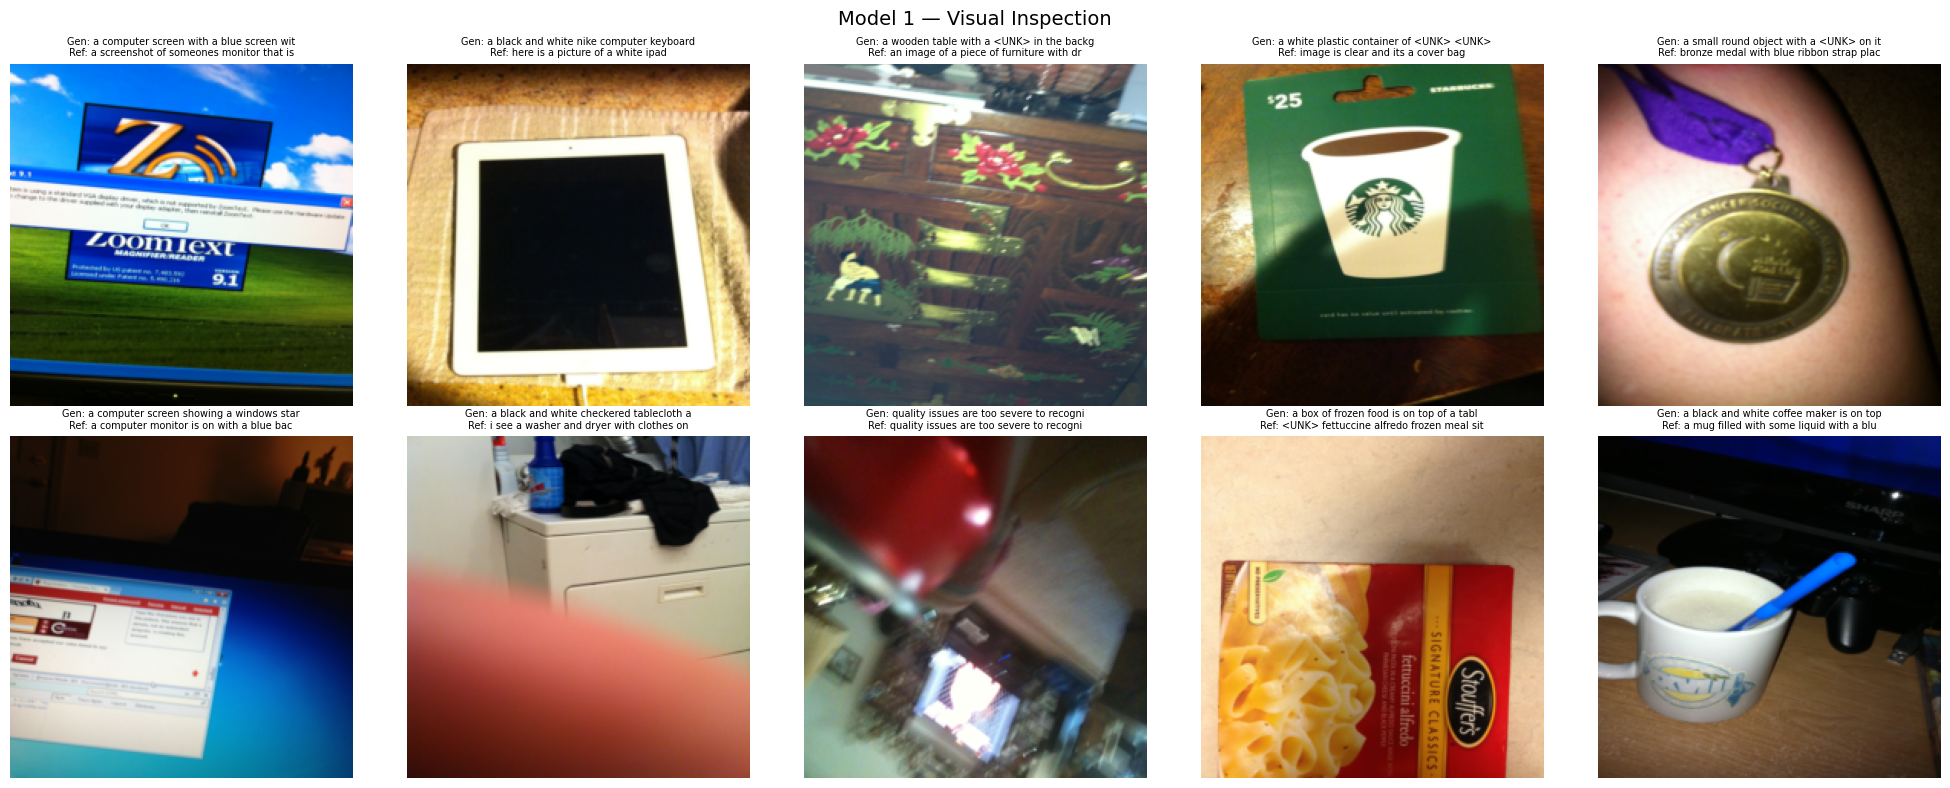

In [ ]:
import matplotlib.pyplot as plt
import random

# Load best model 1
checkpoint = torch.load(MY_CHECKPTS / 'model1_best.pth', map_location=DEVICE)
encoder1.load_state_dict(checkpoint['encoder'])
decoder1.load_state_dict(checkpoint['decoder'])
encoder1.eval()
decoder1.eval()

# Inverse normalisation
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Randomly sample 10 images from test set
sample_indices = random.sample(range(len(test_dataset)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_tensor, cap_tensor = test_dataset[idx]

    # Generate caption
    with torch.no_grad():
        feat = encoder1(img_tensor.unsqueeze(0).to(DEVICE))
        pred_indices = decoder1.generate(feat, max_len=20)
    generated = ' '.join([idx2word.get(j, '<UNK>') for j in pred_indices])

    # Reference caption
    ref = ' '.join([idx2word.get(i.item(), '<UNK>') for i in cap_tensor
                    if i.item() not in [PAD_IDX, SOS_IDX, EOS_IDX]])

    # Display image
    img_show = inv_normalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_show)
    axes[i].axis('off')
    axes[i].set_title(f'Gen: {generated[:40]}\nRef: {ref[:40]}', fontsize=7)

plt.suptitle('Model 1 — Visual Inspection', fontsize=14)
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model1_visual.png')
plt.show()

---
# Group Discussion Summary

After completing Phase 2, the group met to compare Model 1 results and discuss improvements for Model 2.

## Model 1 Architectures

| Student | Encoder | Decoder |
|---------|---------|---------|
| Nian-Ya | ResNet-50 | LSTM |
| Juan | ResNet-50 | GRU |
| Nelkit | MobileNet | LSTM |
| Thom | MobileNet | GRU |
| Maris | GoogLeNet | LSTM |

## Key Observations from Discussion

- All models showed a similar pattern: training loss continued to decrease while validation loss started rising after a few epochs, indicating **overfitting**
- Models using a single global feature vector as the initial hidden state lost spatial information after the first decoding step
- The group agreed that adding an **attention mechanism** would help the decoder dynamically focus on different image regions at each time step, potentially reducing overfitting and improving caption quality

## How This Informed Model 2

Based on the discussion, each student added an attention mechanism to their Model 2:

| Student | Encoder | Decoder |
|---------|---------|---------|
| Nian-Ya | ResNet-50 | LSTM + Bahdanau Attention + Dropout |
| Juan | ResNet-50 | GRU + Bahdanau Attention |
| Nelkit | MobileNet | LSTM + Luong Attention |
| Thom | MobileNet | GRU + Luong Attention |
| Maris | GoogLeNet | Transformer Decoder |

I chose **Bahdanau Attention** and added **Dropout 0.5** to further address overfitting observed in Model 1.

---
# Model 2 — Phase 3 (Refined Architecture)

## Changes Based on Group Discussion

**What changed:** Added Bahdanau Attention mechanism to the decoder, and Dropout (0.5) to reduce overfitting. The encoder (ResNet-50) remains the same as Model 1, but now outputs a spatial feature map (7×7 grid) instead of a single global vector.

**Why:** During the group discussion, we observed that all Model 1 architectures showed overfitting after a few epochs, with val loss rising while train loss continued to decrease. A key insight was that using a single fixed feature vector as the initial hidden state loses spatial information after the first decoding step. Attention addresses this by allowing the decoder to dynamically focus on different image regions at each time step. Dropout was added to further regularise the model.

**What insight drove this decision:** My Model 1 val loss started rising at Epoch 3, suggesting the model was not capturing enough visual detail from a single feature vector. Bahdanau Attention maintains a dynamic connection between the image and the decoder at every step. Additionally, Dropout 0.5 was selected after comparing with Dropout 0.3 — Dropout 0.5 performed better on BLEU-1, BLEU-2, and ROUGE-L metrics.

**Expected improvement:** Higher BLEU-1 and BLEU-2 scores due to better alignment between image regions and generated words, and improved generalisation through Dropout regularisation.

In [ ]:
class AttentionEncoder(nn.Module):
    """ResNet-50 encoder that outputs spatial feature map."""

    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove avgpool and fc, keep spatial features
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.project = nn.Linear(2048, embed_size)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)          # (batch, 2048, 7, 7)
        features = features.permute(0, 2, 3, 1)    # (batch, 7, 7, 2048)
        features = features.reshape(features.size(0), -1, 2048)  # (batch, 49, 2048)
        return self.project(features)               # (batch, 49, embed_size)


class BahdanauAttention(nn.Module):
    """Bahdanau-style attention."""

    def __init__(self, hidden_size, embed_size):
        super().__init__()
        self.W_h = nn.Linear(hidden_size, hidden_size)
        self.W_f = nn.Linear(embed_size, hidden_size)
        self.v   = nn.Linear(hidden_size, 1)

    def forward(self, hidden, features):
        h = self.W_h(hidden).unsqueeze(1)           # (batch, 1, hidden_size)
        f = self.W_f(features)                      # (batch, 49, hidden_size)
        score = self.v(torch.tanh(h + f)).squeeze(-1)  # (batch, 49)
        weights = torch.softmax(score, dim=-1)      # (batch, 49)
        context = (weights.unsqueeze(-1) * features).sum(dim=1)  # (batch, embed_size)
        return context, weights


class AttentionDecoder(nn.Module):
    """LSTM decoder with Bahdanau attention and dropout."""

    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.attention  = BahdanauAttention(hidden_size, embed_size)
        self.lstm_cell  = nn.LSTMCell(embed_size + embed_size, hidden_size)
        self.dropout    = nn.Dropout(0.5)  # Added to reduce overfitting
        self.fc         = nn.Linear(hidden_size, vocab_size)
        self.init_h     = nn.Linear(embed_size, hidden_size)
        self.init_c     = nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):
        batch_size = features.size(0)
        seq_len    = captions.size(1) - 1

        mean_feat = features.mean(dim=1)            # (batch, embed_size)
        h = torch.tanh(self.init_h(mean_feat))      # (batch, hidden_size)
        c = torch.tanh(self.init_c(mean_feat))

        outputs = []
        for t in range(seq_len):
            emb = self.embedding(captions[:, t])    # (batch, embed_size)
            context, _ = self.attention(h, features)
            h, c = self.lstm_cell(torch.cat([emb, context], dim=1), (h, c))
            outputs.append(self.fc(self.dropout(h)))  # Apply dropout before output

        return torch.stack(outputs, dim=1)          # (batch, seq_len, vocab_size)

    def generate(self, features, max_len=20):
        mean_feat = features.mean(dim=1)
        h = torch.tanh(self.init_h(mean_feat))
        c = torch.tanh(self.init_c(mean_feat))

        inputs = torch.tensor([SOS_IDX], device=features.device)
        result = []

        for _ in range(max_len):
            emb = self.embedding(inputs)
            context, _ = self.attention(h, features)
            h, c = self.lstm_cell(torch.cat([emb, context], dim=1), (h, c))
            pred = self.fc(h).argmax(dim=-1)  # No dropout during inference
            token = pred.item()
            if token == EOS_IDX:
                break
            result.append(token)
            inputs = pred

        return result

### Model 2 - Training (Dropout-0.5)

Epoch 1/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.8773 | Val Loss: 3.3946
  ✓ Best model saved (val_loss=3.3946)


Epoch 2/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 3.2297 | Val Loss: 3.1849
  ✓ Best model saved (val_loss=3.1849)


Epoch 3/15:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 13/15 | Train Loss: 1.8659 | Val Loss: 3.2346


Epoch 14/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 1.8089 | Val Loss: 3.2689


Epoch 15/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 1.7553 | Val Loss: 3.2973


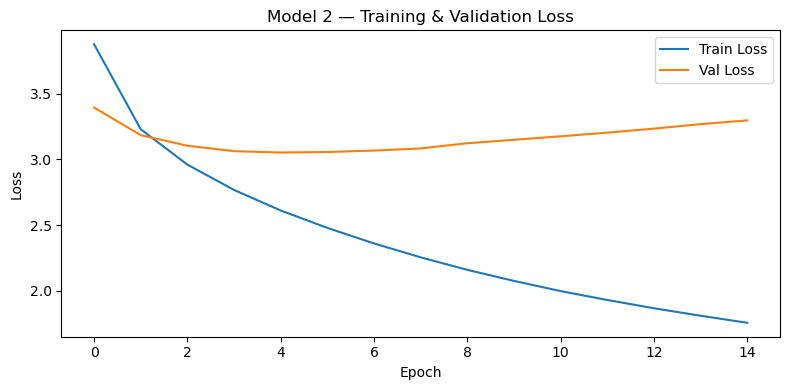

In [ ]:
from tqdm.notebook import tqdm

# Hyperparameters — Model 2
EMBED_SIZE_2  = 256
HIDDEN_SIZE_2 = 512
NUM_LAYERS_2  = 1
EPOCHS_2      = 15
LR_DECODER_2  = 1e-3
LR_ENCODER_2  = 1e-4

encoder2 = AttentionEncoder(EMBED_SIZE_2).to(DEVICE)
decoder2 = AttentionDecoder(EMBED_SIZE_2, HIDDEN_SIZE_2, VOCAB_SIZE, NUM_LAYERS_2).to(DEVICE)

criterion2 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer2 = optim.Adam([
    {'params': decoder2.parameters(), 'lr': LR_DECODER_2},
    {'params': encoder2.project.parameters(), 'lr': LR_ENCODER_2},
])

train_losses2, val_losses2 = [], []
best_val_loss2 = float('inf')

for epoch in range(1, EPOCHS_2 + 1):
    encoder2.train()
    decoder2.train()
    running_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS_2}'):
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        features = encoder2(images)
        outputs  = decoder2(features, captions)

        targets = captions[:, 1:]
        loss = criterion2(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder2.parameters(), max_norm=5)
        optimizer2.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses2.append(train_loss)

    encoder2.eval()
    decoder2.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            features = encoder2(images)
            outputs  = decoder2(features, captions)
            targets  = captions[:, 1:]
            loss = criterion2(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses2.append(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS_2} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss2:
        best_val_loss2 = val_loss
        torch.save({
            'epoch': epoch,
            'encoder': encoder2.state_dict(),
            'decoder': decoder2.state_dict(),
            'optimizer': optimizer2.state_dict(),
            'val_loss': val_loss,
        }, MY_CHECKPTS / 'model2_best.pth')
        print(f'  ✓ Best model saved (val_loss={val_loss:.4f})')

plt.figure(figsize=(8, 4))
plt.plot(train_losses2, label='Train Loss')
plt.plot(val_losses2,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 2 — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model2_loss.png')
plt.show()

### Model 2 - Training (Dropout-0.3)

In [ ]:
class AttentionDecoder03(nn.Module):
    """LSTM decoder with Bahdanau attention and dropout 0.3."""

    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.attention  = BahdanauAttention(hidden_size, embed_size)
        self.lstm_cell  = nn.LSTMCell(embed_size + embed_size, hidden_size)
        self.dropout    = nn.Dropout(0.3)  # Reduced from 0.5 to 0.3
        self.fc         = nn.Linear(hidden_size, vocab_size)
        self.init_h     = nn.Linear(embed_size, hidden_size)
        self.init_c     = nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):
        batch_size = features.size(0)
        seq_len    = captions.size(1) - 1
        mean_feat = features.mean(dim=1)
        h = torch.tanh(self.init_h(mean_feat))
        c = torch.tanh(self.init_c(mean_feat))
        outputs = []
        for t in range(seq_len):
            emb = self.embedding(captions[:, t])
            context, _ = self.attention(h, features)
            h, c = self.lstm_cell(torch.cat([emb, context], dim=1), (h, c))
            outputs.append(self.fc(self.dropout(h)))
        return torch.stack(outputs, dim=1)

    def generate(self, features, max_len=20):
        mean_feat = features.mean(dim=1)
        h = torch.tanh(self.init_h(mean_feat))
        c = torch.tanh(self.init_c(mean_feat))
        inputs = torch.tensor([SOS_IDX], device=features.device)
        result = []
        for _ in range(max_len):
            emb = self.embedding(inputs)
            context, _ = self.attention(h, features)
            h, c = self.lstm_cell(torch.cat([emb, context], dim=1), (h, c))
            pred = self.fc(h).argmax(dim=-1)
            token = pred.item()
            if token == EOS_IDX:
                break
            result.append(token)
            inputs = pred
        return result

Epoch 1/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.7946 | Val Loss: 3.3436
  ✓ Best model saved (val_loss=3.3436)


Epoch 2/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 3.1010 | Val Loss: 3.1484
  ✓ Best model saved (val_loss=3.1484)


Epoch 3/15:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 13/15 | Train Loss: 1.4520 | Val Loss: 3.4280


Epoch 14/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 1.3854 | Val Loss: 3.4840


Epoch 15/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 1.3304 | Val Loss: 3.5373


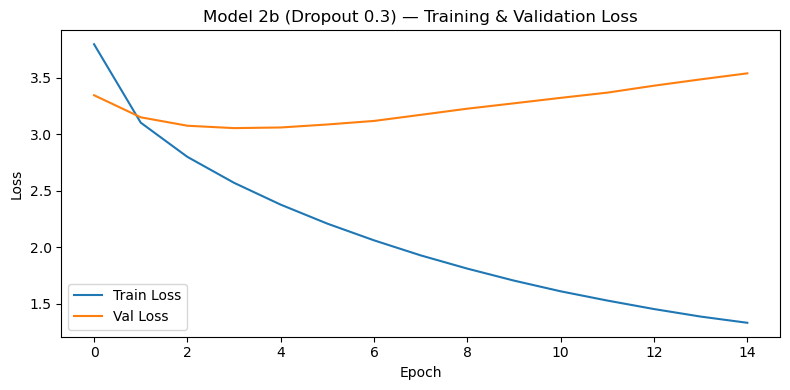

In [ ]:
# Model 2 — Dropout 0.3
encoder2b = AttentionEncoder(EMBED_SIZE_2).to(DEVICE)
decoder2b = AttentionDecoder03(EMBED_SIZE_2, HIDDEN_SIZE_2, VOCAB_SIZE).to(DEVICE)

criterion2b = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer2b = optim.Adam([
    {'params': decoder2b.parameters(), 'lr': LR_DECODER_2},
    {'params': encoder2b.project.parameters(), 'lr': LR_ENCODER_2},
])

train_losses2b, val_losses2b = [], []
best_val_loss2b = float('inf')

for epoch in range(1, EPOCHS_2 + 1):
    encoder2b.train()
    decoder2b.train()
    running_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS_2}'):
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)
        features = encoder2b(images)
        outputs  = decoder2b(features, captions)
        targets  = captions[:, 1:]
        loss = criterion2b(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        optimizer2b.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder2b.parameters(), max_norm=5)
        optimizer2b.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses2b.append(train_loss)

    encoder2b.eval()
    decoder2b.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            features = encoder2b(images)
            outputs  = decoder2b(features, captions)
            targets  = captions[:, 1:]
            loss = criterion2b(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses2b.append(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS_2} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss2b:
        best_val_loss2b = val_loss
        torch.save({
            'epoch': epoch,
            'encoder': encoder2b.state_dict(),
            'decoder': decoder2b.state_dict(),
            'optimizer': optimizer2b.state_dict(),
            'val_loss': val_loss,
        }, MY_CHECKPTS / 'model2b_best.pth')
        print(f'  ✓ Best model saved (val_loss={val_loss:.4f})')

plt.figure(figsize=(8, 4))
plt.plot(train_losses2b, label='Train Loss')
plt.plot(val_losses2b,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 2b (Dropout 0.3) — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model2b_loss.png')
plt.show()

In [ ]:
# Evaluate Model 2 (Dropout 0.3)
checkpoint2b = torch.load(MY_CHECKPTS / 'model2b_best.pth', map_location=DEVICE)
encoder2b.load_state_dict(checkpoint2b['encoder'])
decoder2b.load_state_dict(checkpoint2b['decoder'])
encoder2b.eval()
decoder2b.eval()

references2b   = []
hypotheses2b   = []
generated_strs2b = []
reference_strs2b = []

with torch.no_grad():
    for images, captions, lengths in tqdm(test_loader, desc='Evaluating Model 2b'):
        images   = images.to(DEVICE)
        features = encoder2b(images)

        for i in range(images.size(0)):
            feat = features[i].unsqueeze(0)
            pred_indices = decoder2b.generate(feat, max_len=20)
            hypothesis = [idx2word.get(idx, '<UNK>') for idx in pred_indices]
            hypotheses2b.append(hypothesis)
            generated_strs2b.append(' '.join(hypothesis))

            cap = captions[i].tolist()
            ref = [idx2word.get(idx, '<UNK>') for idx in cap
                   if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            references2b.append([ref])
            reference_strs2b.append(' '.join(ref))

smoother = SmoothingFunction().method1
bleu1_m2b = corpus_bleu(references2b, hypotheses2b, weights=(1,0,0,0), smoothing_function=smoother)
bleu2_m2b = corpus_bleu(references2b, hypotheses2b, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu3_m2b = corpus_bleu(references2b, hypotheses2b, weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
bleu4_m2b = corpus_bleu(references2b, hypotheses2b, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rougel_scores2b = [scorer.score(ref, hyp)['rougeL'].fmeasure
                   for ref, hyp in zip(reference_strs2b, generated_strs2b)]
rougel2b = sum(rougel_scores2b) / len(rougel_scores2b)

# Compare Model 2 vs Model 2b
print('=' * 60)
print(f'{"Metric":<10} {"Model 2 (Dropout 0.5)":>20} {"Model 2b (Dropout 0.3)":>20}')
print('=' * 60)
print(f'{"BLEU-1":<10} {bleu1_m2:>20.4f} {bleu1_m2b:>20.4f}')
print(f'{"BLEU-2":<10} {bleu2_m2:>20.4f} {bleu2_m2b:>20.4f}')
print(f'{"BLEU-3":<10} {bleu3_m2:>20.4f} {bleu3_m2b:>20.4f}')
print(f'{"BLEU-4":<10} {bleu4_m2:>20.4f} {bleu4_m2b:>20.4f}')
print(f'{"ROUGE-L":<10} {rougel2:>20.4f} {rougel2b:>20.4f}')
print('=' * 60)

/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_56228/1247653147.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint2b = torch.load(MY_CHECKPTS / 'mode

Evaluating Model 2b:   0%|          | 0/118 [00:00<?, ?it/s]

Metric            Model 2 (0.5)       Model 2b (0.3)
BLEU-1                   0.2839               0.2810
BLEU-2                   0.1784               0.1780
BLEU-3                   0.1314               0.1329
BLEU-4                   0.1025               0.1051
ROUGE-L                  0.2914               0.2911


### Dropout Hyperparameter Selection

After comparing Dropout 0.5 and Dropout 0.3, **Dropout 0.5 was selected** as the final Model 2 configuration based on the following results:

| Metric | Dropout 0.5 | Dropout 0.3 | Winner |
|--------|-------------|-------------|--------|
| BLEU-1 | 0.2839 | 0.2810 | 0.5 |
| BLEU-2 | 0.1784 | 0.1780 | 0.5 |
| BLEU-3 | 0.1314 | 0.1329 | 0.3 |
| BLEU-4 | 0.1025 | 0.1051 | 0.3 |
| ROUGE-L | 0.2914 | 0.2911 | 0.5 |

Dropout 0.5 wins on 3 out of 5 metrics and is therefore used for the final Model 1 vs Model 2 comparison.

### Model 2 (Dropout 0.5) — Visual inspection

In [ ]:
sample_indices = random.sample(range(len(test_dataset)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_tensor, cap_tensor = test_dataset[idx]

    # Generate caption with Model 2
    with torch.no_grad():
        feat = encoder2(img_tensor.unsqueeze(0).to(DEVICE))
        pred_indices = decoder2.generate(feat, max_len=20)
    generated = ' '.join([idx2word.get(j, '<UNK>') for j in pred_indices])

    # Reference caption
    ref = ' '.join([idx2word.get(k.item(), '<UNK>') for k in cap_tensor
                    if k.item() not in [PAD_IDX, SOS_IDX, EOS_IDX]])

    # Display image
    img_show = inv_normalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_show)
    axes[i].axis('off')
    axes[i].set_title(f'Gen: {generated[:40]}\nRef: {ref[:40]}', fontsize=7)

plt.suptitle('Model 2 — Visual Inspection', fontsize=14)
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model2_visual.png')
plt.show()

### Model 2 — Evaluation & comparison vs. Model 1

/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_56228/3620868641.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint2 = torch.load(MY_CHECKPTS / 'model

Evaluating Model 2:   0%|          | 0/118 [00:00<?, ?it/s]

Metric             Model 1         Model 2
BLEU-1              0.2774          0.2839
BLEU-2              0.1782          0.1784
BLEU-3              0.1372          0.1314
BLEU-4              0.1115          0.1025
ROUGE-L             0.2883          0.2914


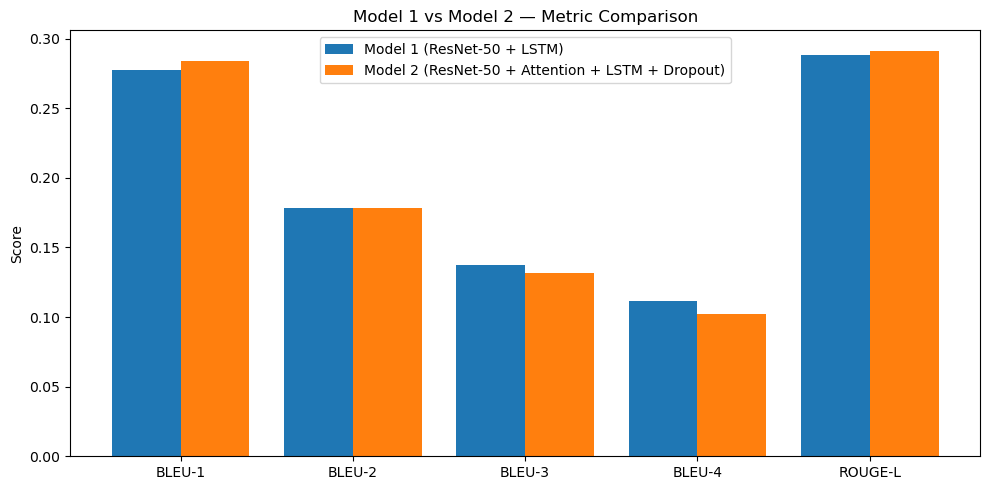

In [ ]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt', quiet=True)

# Load best Model 2
checkpoint2 = torch.load(MY_CHECKPTS / 'model2_best.pth', map_location=DEVICE)
encoder2.load_state_dict(checkpoint2['encoder'])
decoder2.load_state_dict(checkpoint2['decoder'])
encoder2.eval()
decoder2.eval()

# Generate captions and compute BLEU for Model 2
references2   = []
hypotheses2   = []
generated_strs2 = []
reference_strs2 = []

with torch.no_grad():
    for images, captions, lengths in tqdm(test_loader, desc='Evaluating Model 2'):
        images   = images.to(DEVICE)
        features = encoder2(images)

        for i in range(images.size(0)):
            feat = features[i].unsqueeze(0)
            pred_indices = decoder2.generate(feat, max_len=20)
            hypothesis = [idx2word.get(idx, '<UNK>') for idx in pred_indices]
            hypotheses2.append(hypothesis)
            generated_strs2.append(' '.join(hypothesis))

            cap = captions[i].tolist()
            ref = [idx2word.get(idx, '<UNK>') for idx in cap
                   if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            references2.append([ref])
            reference_strs2.append(' '.join(ref))

# Compute BLEU-1 to BLEU-4
smoother = SmoothingFunction().method1
bleu1_m2 = corpus_bleu(references2, hypotheses2, weights=(1,0,0,0), smoothing_function=smoother)
bleu2_m2 = corpus_bleu(references2, hypotheses2, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu3_m2 = corpus_bleu(references2, hypotheses2, weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
bleu4_m2 = corpus_bleu(references2, hypotheses2, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

# Compute ROUGE-L for Model 2
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rougel_scores2 = [scorer.score(ref, hyp)['rougeL'].fmeasure
                  for ref, hyp in zip(reference_strs2, generated_strs2)]
rougel2 = sum(rougel_scores2) / len(rougel_scores2)

# Side-by-side comparison table
print('=' * 55)
print(f'{"Metric":<10} {"Model 1":>15} {"Model 2":>15}')
print('=' * 55)
print(f'{"BLEU-1":<10} {bleu1:>15.4f} {bleu1_m2:>15.4f}')
print(f'{"BLEU-2":<10} {bleu2:>15.4f} {bleu2_m2:>15.4f}')
print(f'{"BLEU-3":<10} {bleu3:>15.4f} {bleu3_m2:>15.4f}')
print(f'{"BLEU-4":<10} {bleu4:>15.4f} {bleu4_m2:>15.4f}')
print(f'{"ROUGE-L":<10} {rougel:>15.4f} {rougel2:>15.4f}')
print('=' * 55)

# Plot comparison
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'ROUGE-L']
model1_scores = [bleu1, bleu2, bleu3, bleu4, rougel]
model2_scores = [bleu1_m2, bleu2_m2, bleu3_m2, bleu4_m2, rougel2]

x = range(len(metrics))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], model1_scores, width=0.4, label='Model 1 (ResNet-50 + LSTM)')
plt.bar([i + 0.2 for i in x], model2_scores, width=0.4, label='Model 2 (ResNet-50 + Attention + LSTM + Dropout)')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model 1 vs Model 2 — Metric Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model2_comparison.png')
plt.show()